# Exp77: Segmented Normative Constructors

Ноутбук для интерактивного прогона и разбора первых сегментных конструкторов норматива.

Сегменты:
- `stable`
- `bakery_driven`

Логика:
- `stable` -> release-aware weekday normative
- `bakery_driven` -> bakery normative total * stable SKU share

In [1]:
from __future__ import annotations

import importlib.util
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

DAILY_PATH = ROOT / "data/processed/sku_daily_research_panel.csv"
SEGMENT_MAP_PATH = ROOT / "src/experiments_v2/75_normative_demand_map/predictability_and_structure_map.csv"
OUTPUT_DIR = ROOT / "reports/normative_segmented_constructors_exp77"
MODULE_PATH = ROOT / "src/experiments_v2/77_segmented_normative_constructors/run.py"

spec = importlib.util.spec_from_file_location("exp77_run", MODULE_PATH)
exp77 = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(exp77)

ROOT, DAILY_PATH.exists(), SEGMENT_MAP_PATH.exists(), MODULE_PATH.exists()

(WindowsPath('c:/Users/dns/Desktop/Projects/demand-forecasting-model'),
 True,
 True,
 True)

In [8]:
from pathlib import Path

import pandas as pd

DATE_COL = "date"
BAKERY_COL = "bakery_id"
SKU_COL = "product_id"
SALES_COL = "observed_sales_qty"
DOW_COL = "dow"


def load_daily_dataset_chunked(
    path: str | Path,
    segment_map: pd.DataFrame,
    chunksize: int = 250_000,
) -> pd.DataFrame:
    usecols = [
        DATE_COL,
        BAKERY_COL,
        SKU_COL,
        SALES_COL,
        DOW_COL,
        "release_qty",
        "bakery_sales_qty_total",
        "sku_sales_share_in_bakery_day",
    ]

    segment_map = segment_map.copy()
    segment_map[BAKERY_COL] = segment_map[BAKERY_COL].astype(str)
    segment_map[SKU_COL] = segment_map[SKU_COL].astype(str)

    target_pairs = set(
        zip(
            segment_map[BAKERY_COL],
            segment_map[SKU_COL],
        )
    )

    parts = []

    for chunk in pd.read_csv(
        path,
        encoding="utf-8-sig",
        usecols=usecols,
        chunksize=chunksize,
        low_memory=True,
    ):
        chunk[BAKERY_COL] = chunk[BAKERY_COL].astype(str)
        chunk[SKU_COL] = chunk[SKU_COL].astype(str)

        pair_key = list(zip(chunk[BAKERY_COL], chunk[SKU_COL]))
        chunk = chunk.loc[[key in target_pairs for key in pair_key]].copy()

        if chunk.empty:
            continue

        chunk[DATE_COL] = pd.to_datetime(chunk[DATE_COL], errors="coerce")
        chunk = chunk.dropna(subset=[DATE_COL, BAKERY_COL, SKU_COL])

        chunk[SALES_COL] = pd.to_numeric(chunk[SALES_COL], errors="coerce").fillna(0.0)
        chunk["release_qty"] = pd.to_numeric(chunk["release_qty"], errors="coerce").fillna(0.0)
        chunk["bakery_sales_qty_total"] = pd.to_numeric(
            chunk["bakery_sales_qty_total"], errors="coerce"
        ).fillna(0.0)
        chunk["sku_sales_share_in_bakery_day"] = pd.to_numeric(
            chunk["sku_sales_share_in_bakery_day"], errors="coerce"
        )

        if DOW_COL not in chunk.columns:
            chunk[DOW_COL] = chunk[DATE_COL].dt.weekday
        else:
            dow_numeric = pd.to_numeric(chunk[DOW_COL], errors="coerce")
            chunk[DOW_COL] = dow_numeric.fillna(chunk[DATE_COL].dt.weekday).astype(int)

        parts.append(chunk)

    if not parts:
        return pd.DataFrame(columns=usecols)

    df = pd.concat(parts, ignore_index=True)
    df[BAKERY_COL] = df[BAKERY_COL].astype(str)
    df[SKU_COL] = df[SKU_COL].astype(str)

    return df.sort_values([BAKERY_COL, SKU_COL, DATE_COL]).reset_index(drop=True)

## 1. Сегменты и ожидаемый объём

Сначала смотрим, сколько у нас целевых пар и сколько строк панельных данных они занимают.

In [2]:
segment_map_full = pd.read_csv(SEGMENT_MAP_PATH, encoding="utf-8-sig")
segment_map_target = exp77.load_segment_map(SEGMENT_MAP_PATH)

segment_counts = (
    segment_map_full["primary_segment"]
    .value_counts(dropna=False)
    .rename_axis("primary_segment")
    .reset_index(name="pairs")
)

panel_pairs = pd.read_csv(
    DAILY_PATH,
    encoding="utf-8-sig",
    usecols=["bakery_id", "product_id"],
).drop_duplicates()

target_pairs = segment_map_target[["bakery_id", "product_id", "primary_segment"]].drop_duplicates()
target_pair_rows = panel_pairs.merge(target_pairs, on=["bakery_id", "product_id"], how="inner")

display(segment_counts)
display(
    target_pairs["primary_segment"].value_counts().rename_axis("primary_segment").reset_index(name="pairs")
)
print(f"Target pair rows in panel: {len(target_pair_rows):,}")
print(f"Target pairs: {len(target_pairs):,}")

,primary_segment,pairs
0,noisy,30197
1,intermittent,13180
2,amplitude_unstable,12005
3,trend_dominated,2280
4,bakery_driven,433
5,stable,257
6,high_censoring,11


,primary_segment,pairs
0,bakery_driven,433
1,stable,257


Target pair rows in panel: 690
Target pairs: 690


## 2. Загружаем только нужные колонки panel и строим норматив

Здесь используется логика из `src/experiments_v2/77_segmented_normative_constructors/run.py`.

In [10]:
segment_map = exp77.load_segment_map(SEGMENT_MAP_PATH).copy()
segment_map["bakery_id"] = segment_map["bakery_id"].astype(str)
segment_map["product_id"] = segment_map["product_id"].astype(str)

daily_df = load_daily_dataset_chunked(DAILY_PATH, segment_map, chunksize=250_000)

result_df = exp77.build_segmented_normative(daily_df, segment_map)
pair_summary = exp77.build_pair_summary(result_df)
segment_summary = exp77.build_segment_summary(pair_summary)
metrics = exp77.build_metrics(result_df, pair_summary)

print(json.dumps(metrics, ensure_ascii=False, indent=2))

{
  "built_rows": 92639,
  "built_pairs": 690,
  "built_segments": {
    "bakery_driven": 433,
    "stable": 257
  },
  "constructor_counts": {
    "stable_release_weekday": 90811,
    "bakery_total_x_sku_share": 1828
  }
}


## 3. Сводка по сегментам

Основные диагностические поля:
- `candidate_to_observed_ratio`
- `candidate_corr_with_observed`
- `candidate_corr_with_release`
- `candidate_corr_with_bakery_total`

In [11]:
display(segment_summary.sort_values(["primary_segment", "pairs"], ascending=[True, False]))

display(
    pair_summary.groupby("primary_segment", dropna=False)
    .agg(
        pairs=("primary_segment", "size"),
        observed_mean=("observed_mean", "mean"),
        candidate_mean=("candidate_mean", "mean"),
        candidate_corr_with_observed=("candidate_corr_with_observed", "mean"),
        candidate_corr_with_release=("candidate_corr_with_release", "mean"),
        candidate_corr_with_bakery_total=("candidate_corr_with_bakery_total", "mean"),
    )
    .reset_index()
)


,primary_segment,segment_constructor_name,pairs,observed_mean,candidate_mean,candidate_to_observed_ratio,candidate_corr_with_observed,candidate_corr_with_release,candidate_corr_with_bakery_total
0,bakery_driven,bakery_total_x_sku_share,433,8.451431,0.317923,0.036742,0.588682,0.258776,0.578250
1,stable,stable_release_weekday,257,25.829408,45.632549,1.837868,0.718008,0.676675,0.589568


,primary_segment,pairs,observed_mean,candidate_mean,candidate_corr_with_observed,candidate_corr_with_release,candidate_corr_with_bakery_total
0,bakery_driven,433,8.451431,0.317923,0.588682,0.258776,0.578250
1,stable,257,25.829408,45.632549,0.718008,0.676675,0.589568


## 4. Примеры лучших и худших пар

Удобно смотреть глазами, где конструктор выглядит правдоподобно, а где нет.

In [12]:
stable_examples = pair_summary.loc[pair_summary["primary_segment"] == "stable"].sort_values(
    ["candidate_corr_with_release", "candidate_corr_with_observed"], ascending=False
)
bakery_examples = pair_summary.loc[pair_summary["primary_segment"] == "bakery_driven"].sort_values(
    ["candidate_corr_with_bakery_total", "candidate_corr_with_observed"], ascending=False
)

print("Stable: top examples")
display(stable_examples.head(10))

print("Stable: weakest examples")
display(stable_examples.tail(10))

print("Bakery-driven: top examples")
display(bakery_examples.head(10))

print("Bakery-driven: weakest examples")
display(bakery_examples.tail(10))

Stable: top examples


,bakery_id,product_id,primary_segment,segment_constructor_name,observed_mean,candidate_mean,release_mean,candidate_to_observed_ratio,candidate_corr_with_observed,candidate_corr_with_release,candidate_corr_with_bakery_total
32,106,4629,stable,stable_release_weekday,19.906832,52.775576,63.016563,2.651129,0.777141,0.881648,0.457717
18,102,1844,stable,stable_release_weekday,22.863354,41.282015,45.689441,1.805597,0.830594,0.875130,0.399262
593,66,10608,stable,stable_release_weekday,7.031250,14.507753,14.468750,2.063325,0.758110,0.866467,0.719683
25,106,10346,stable,stable_release_weekday,50.952381,119.049909,139.610766,2.336494,0.733702,0.854888,0.468025
667,89,11213,stable,stable_release_weekday,11.382114,17.156967,24.093496,1.507362,0.834322,0.853763,0.298485
594,66,10656,stable,stable_release_weekday,8.327381,16.387435,17.119048,1.967898,0.775702,0.852856,0.771259
292,22,61,stable,stable_release_weekday,51.757576,97.639584,102.545455,1.886479,0.869701,0.852140,0.942515
141,158,10347,stable,stable_release_weekday,20.095238,78.415498,107.105590,3.902193,0.778234,0.849360,0.194082
659,85,11251,stable,stable_release_weekday,13.523810,26.818662,30.761905,1.983070,0.861613,0.848270,0.844529
89,142,10732,stable,stable_release_weekday,8.080745,18.445707,23.701863,2.282674,0.804288,0.841995,0.666350


Stable: weakest examples


,bakery_id,product_id,primary_segment,segment_constructor_name,observed_mean,candidate_mean,release_mean,candidate_to_observed_ratio,candidate_corr_with_observed,candidate_corr_with_release,candidate_corr_with_bakery_total
283,217,4947,stable,stable_release_weekday,3.625000,5.099591,6.625000,1.406784,0.906637,0.405762,0.584684
270,201,10556,stable,stable_release_weekday,14.400452,22.063797,34.004525,1.532160,0.791373,0.398430,0.406758
603,70,10346,stable,stable_release_weekday,43.774327,79.926601,101.285714,1.825878,0.725156,0.389345,0.763385
462,261,11305,stable,stable_release_weekday,2.850000,7.547810,10.400000,2.648354,0.837771,0.373940,0.216420
605,70,1120,stable,stable_release_weekday,4.040000,9.004925,10.080000,2.228942,0.723658,0.363223,0.698839
513,35,11473,stable,stable_release_weekday,2.000000,3.300000,5.391304,1.650000,0.826009,0.340785,0.440629
590,65,10961,stable,stable_release_weekday,1.708333,3.088800,3.166667,1.808078,0.809245,0.286924,0.441951
477,266,67,stable,stable_release_weekday,6.000000,15.512549,19.000000,2.585425,0.832155,0.247089,0.508893
160,161,517,stable,stable_release_weekday,9.095238,15.588207,20.501035,1.713887,0.680207,0.209644,0.365135
625,79,11534,stable,stable_release_weekday,5.642857,10.206646,19.928571,1.808773,0.898550,0.010215,0.615936


Bakery-driven: top examples


,bakery_id,product_id,primary_segment,segment_constructor_name,observed_mean,candidate_mean,release_mean,candidate_to_observed_ratio,candidate_corr_with_observed,candidate_corr_with_release,candidate_corr_with_bakery_total
69,125,11496,bakery_driven,bakery_total_x_sku_share,9.714286,4.261385,0.000000,0.438672,0.980168,NaN,0.987908
293,220,10080,bakery_driven,bakery_total_x_sku_share,9.250000,3.067159,0.000000,0.331585,0.905350,NaN,0.928760
440,254,10080,bakery_driven,bakery_total_x_sku_share,13.857143,7.509165,0.000000,0.541899,0.859533,NaN,0.911265
237,19,10955,bakery_driven,bakery_total_x_sku_share,8.300000,6.168935,0.000000,0.743245,0.640678,NaN,0.838994
231,188,10082,bakery_driven,bakery_total_x_sku_share,8.125000,1.210513,0.000000,0.148986,0.703319,NaN,0.822955
613,74,11428,bakery_driven,bakery_total_x_sku_share,2.666667,2.729510,5.777778,1.023566,0.620518,0.650540,0.774135
467,262,11483,bakery_driven,bakery_total_x_sku_share,43.625000,23.785822,68.500000,0.545234,0.896663,-0.010010,0.725375
391,235,10347,bakery_driven,bakery_total_x_sku_share,8.375000,9.662878,2.500000,1.153776,0.727966,-0.071776,0.721421
355,229,11496,bakery_driven,bakery_total_x_sku_share,5.666667,2.863102,0.000000,0.505253,0.018730,NaN,0.711798
574,59,10955,bakery_driven,bakery_total_x_sku_share,4.125000,1.545691,0.000000,0.374713,0.797651,NaN,0.703167


Bakery-driven: weakest examples


,bakery_id,product_id,primary_segment,segment_constructor_name,observed_mean,candidate_mean,release_mean,candidate_to_observed_ratio,candidate_corr_with_observed,candidate_corr_with_release,candidate_corr_with_bakery_total
675,93,10647,bakery_driven,bakery_total_x_sku_share,0.319000,0.0,0.00,0.0,NaN,NaN,NaN
676,93,10669,bakery_driven,bakery_total_x_sku_share,2.000000,0.0,0.00,0.0,NaN,NaN,NaN
677,93,11496,bakery_driven,bakery_total_x_sku_share,11.500000,0.0,0.00,0.0,NaN,NaN,NaN
678,93,87,bakery_driven,bakery_total_x_sku_share,1.800000,0.0,3.60,0.0,NaN,NaN,NaN
679,94,11496,bakery_driven,bakery_total_x_sku_share,8.666667,0.0,0.00,0.0,NaN,NaN,NaN
680,95,10717,bakery_driven,bakery_total_x_sku_share,1.500000,0.0,6.75,0.0,NaN,NaN,NaN
681,95,11427,bakery_driven,bakery_total_x_sku_share,1.333333,0.0,3.00,0.0,NaN,NaN,NaN
682,95,11496,bakery_driven,bakery_total_x_sku_share,13.000000,0.0,0.00,0.0,NaN,NaN,NaN
683,95,1982,bakery_driven,bakery_total_x_sku_share,1.000000,0.0,0.00,0.0,NaN,NaN,NaN
685,95,96,bakery_driven,bakery_total_x_sku_share,1.666667,0.0,2.00,0.0,NaN,NaN,NaN


## 5. Смотреть дневной ряд по одной паре

Поменяй `bakery_id` и `product_id` на интересующую пару.

,date,primary_segment,observed_sales_qty,release_qty,bakery_sales_qty_total,sku_sales_share_in_bakery_day,bakery_normative_total,segment_normative_candidate,segment_constructor_name
8922,2025-01-15,stable,42.0,164.0,1835.0,0.022888,1896.631996,127.413541,stable_release_weekday
8923,2025-01-16,stable,40.0,160.0,1675.0,0.023881,1882.845468,140.479407,stable_release_weekday
8924,2025-01-17,stable,40.0,160.0,1779.0,0.022485,1909.363000,125.705585,stable_release_weekday
8925,2025-01-18,stable,25.0,100.0,1140.0,0.021930,1314.494218,90.436287,stable_release_weekday
8926,2025-01-19,stable,20.0,60.0,921.5,0.021704,1010.793224,70.453198,stable_release_weekday
8927,2025-01-20,stable,38.0,160.0,1756.0,0.021640,1836.510365,132.025023,stable_release_weekday
8928,2025-01-21,stable,30.0,160.0,1624.0,0.018473,1874.361728,134.586958,stable_release_weekday
8929,2025-01-22,stable,41.0,160.0,1744.0,0.023509,1935.696953,127.793718,stable_release_weekday
8930,2025-01-23,stable,48.0,160.0,1651.0,0.029073,1882.845468,141.317733,stable_release_weekday
8931,2025-01-24,stable,35.0,160.0,1800.0,0.019444,1948.690179,126.080666,stable_release_weekday


<Axes: xlabel='date'>

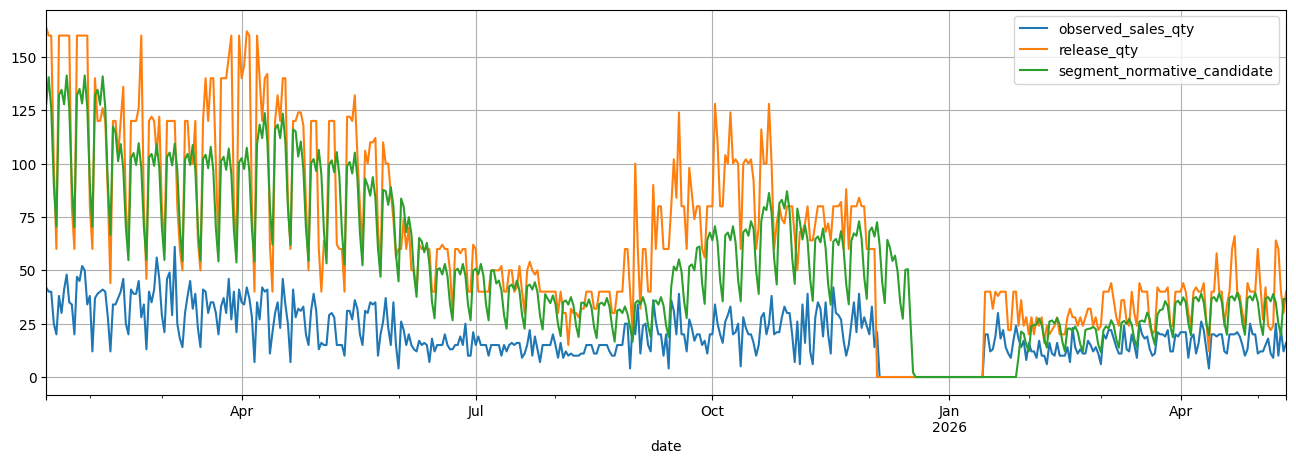

In [13]:
bakery_id = stable_examples.iloc[0]["bakery_id"] if not stable_examples.empty else None
product_id = stable_examples.iloc[0]["product_id"] if not stable_examples.empty else None

example = result_df.loc[
    (result_df["bakery_id"] == bakery_id) & (result_df["product_id"] == product_id),
    [
        "date",
        "primary_segment",
        "observed_sales_qty",
        "release_qty",
        "bakery_sales_qty_total",
        "sku_sales_share_in_bakery_day",
        "bakery_normative_total",
        "segment_normative_candidate",
        "segment_constructor_name",
    ],
].copy()

display(example.head(30))
example.set_index("date")[["observed_sales_qty", "release_qty", "segment_normative_candidate"]].plot(figsize=(16, 5), grid=True)

## 6. Сохранить артефакты

Если нужно выгрузить результаты из ноутбука в `reports/`.

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
result_df.to_csv(OUTPUT_DIR / "segmented_normative_daily.csv", index=False, encoding="utf-8-sig")
pair_summary.to_csv(OUTPUT_DIR / "segmented_normative_pair_summary.csv", index=False, encoding="utf-8-sig")
segment_summary.to_csv(OUTPUT_DIR / "segmented_normative_segment_summary.csv", index=False, encoding="utf-8-sig")
(OUTPUT_DIR / "metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")
print(OUTPUT_DIR)

c:\Users\dns\Desktop\Projects\demand-forecasting-model\reports\normative_segmented_constructors_exp77


In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("default")

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

def plot_bakery_pair(bakery_id, product_id, tail_days=None):
    bakery_id = str(bakery_id)
    product_id = str(product_id)

    plot_df = result_df.loc[
        (result_df["bakery_id"].astype(str) == bakery_id)
        & (result_df["product_id"].astype(str) == product_id)
    ].copy()

    if plot_df.empty:
        print(f"No rows found for bakery_id={bakery_id}, product_id={product_id}")
        return

    plot_df = plot_df.sort_values("date")

    if tail_days is not None:
        plot_df = plot_df.tail(tail_days)

    display(
        plot_df[
            [
                "date",
                "observed_sales_qty",
                "segment_normative_candidate",
                "bakery_normative_total",
                "sku_sales_share_in_bakery_day",
            ]
        ].head(10)
    )

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(
        plot_df["date"],
        plot_df["observed_sales_qty"],
        label="observed_sales_qty",
        linewidth=2,
        color="tab:blue",
    )
    axes[0].plot(
        plot_df["date"],
        plot_df["segment_normative_candidate"],
        label="segment_normative_candidate",
        linewidth=2,
        color="tab:orange",
    )
    axes[0].plot(
        plot_df["date"],
        plot_df["bakery_normative_total"],
        label="bakery_normative_total",
        linewidth=1.5,
        color="tab:green",
        alpha=0.8,
    )
    axes[0].set_title(f"bakery_id={bakery_id}, product_id={product_id}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        plot_df["date"],
        plot_df["sku_sales_share_in_bakery_day"],
        label="sku_sales_share_in_bakery_day",
        linewidth=2,
        color="tab:red",
    )
    axes[1].set_title("SKU share in bakery")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

,date,observed_sales_qty,segment_normative_candidate,bakery_normative_total,sku_sales_share_in_bakery_day
60399,2026-04-06,6.0,6.360338,505.967008,0.012571
60400,2026-04-07,5.0,6.082263,483.846064,0.008400
60401,2026-04-08,5.0,7.265552,577.977075,0.008399
60402,2026-04-09,6.0,6.735029,535.773808,0.010466
60403,2026-04-10,22.0,8.340073,663.455617,0.032343
60404,2026-04-11,43.0,9.468161,753.195391,0.054798
60405,2026-04-12,10.0,8.312740,661.281273,0.014363


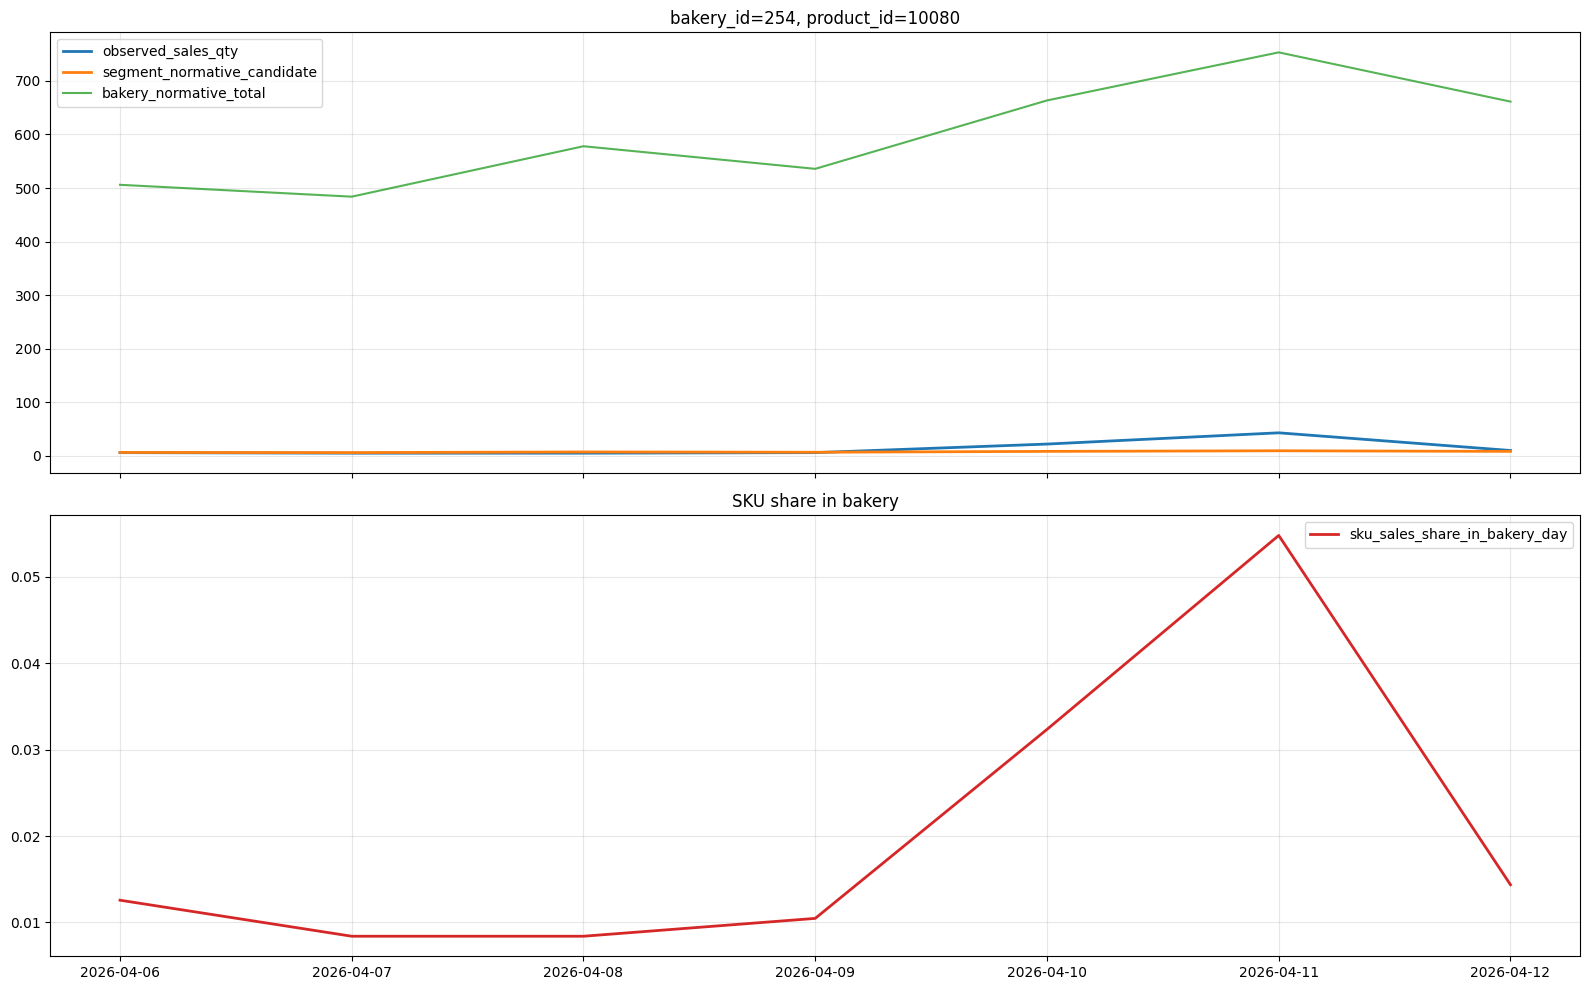

In [21]:
row = best_bakery_pairs.iloc[2]
plot_bakery_pair(row["bakery_id"], row["product_id"], tail_days=60)

In [22]:
row = best_bakery_pairs.iloc[0]

test_df = result_df.loc[
    (result_df["bakery_id"].astype(str) == str(row["bakery_id"]))
    & (result_df["product_id"].astype(str) == str(row["product_id"]))
].copy()

print(test_df.shape)
display(test_df[["date", "observed_sales_qty", "segment_normative_candidate"]].head(20))
display(test_df[["date", "observed_sales_qty", "segment_normative_candidate"]].tail(20))

(7, 16)


,date,observed_sales_qty,segment_normative_candidate
16426,2026-04-06,2.0,3.711207
16427,2026-04-07,4.0,3.759386
16428,2026-04-08,2.0,3.968857
16429,2026-04-09,6.0,3.608760
16430,2026-04-10,15.0,4.758422
16431,2026-04-11,37.0,6.362085
16432,2026-04-12,2.0,3.660980


,date,observed_sales_qty,segment_normative_candidate
16426,2026-04-06,2.0,3.711207
16427,2026-04-07,4.0,3.759386
16428,2026-04-08,2.0,3.968857
16429,2026-04-09,6.0,3.608760
16430,2026-04-10,15.0,4.758422
16431,2026-04-11,37.0,6.362085
16432,2026-04-12,2.0,3.660980
